In [2]:
import pandas as pd

train = pd.read_excel("DeepX_train.xlsx")
val = pd.read_excel("DeepX_validation.xlsx")
test = pd.read_excel("DeepX_unlabeled.xlsx")

In [3]:
print(train.shape)
print(train.columns)
train.head()

(1971, 9)
Index(['review_id', 'review_text', 'star_rating', 'date', 'business_name',
       'business_category', 'platform', 'aspects', 'aspect_sentiments'],
      dtype='object')


,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,قبل شهر,بيت لحم Beet Lahm,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,قبل شهر,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,قبل سنة,The Best Restaurant,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [4]:
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1971 entries, 0 to 1970
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   review_id          1971 non-null   int64 
 1   review_text        1971 non-null   object
 2   star_rating        1971 non-null   int64 
 3   date               1971 non-null   object
 4   business_name      1971 non-null   object
 5   business_category  1971 non-null   object
 6   platform           1971 non-null   object
 7   aspects            1971 non-null   object
 8   aspect_sentiments  1971 non-null   object
dtypes: int64(2), object(7)
memory usage: 138.7+ KB


review_id            0
review_text          0
star_rating          0
date                 0
business_name        0
business_category    0
platform             0
aspects              0
aspect_sentiments    0
dtype: int64

In [5]:
import ast

train['aspects'] = train['aspects'].apply(ast.literal_eval)
train['aspect_sentiments'] = train['aspect_sentiments'].apply(ast.literal_eval)

In [6]:
print(type(train['aspects'][0]))
print(type(train['aspect_sentiments'][0]))

<class 'list'>
<class 'dict'>


In [7]:
train['length'] = train['review_text'].astype(str).apply(len)

train['length'].describe()

count    1971.000000
mean      119.223237
std       145.344526
min         2.000000
25%        36.000000
50%        75.000000
75%       148.000000
max      1526.000000
Name: length, dtype: float64

<Axes: >

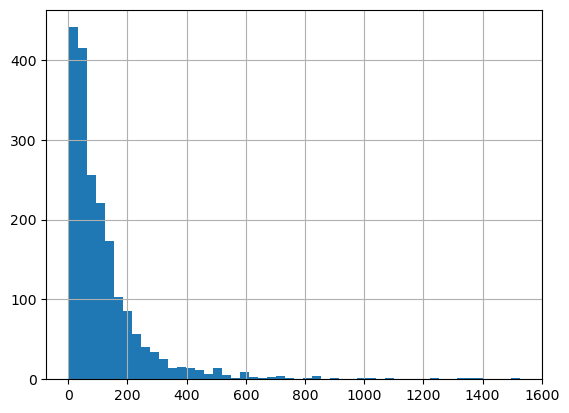

In [8]:
train['length'].hist(bins=50)

In [9]:
train.sample(10)

,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments,length
56,8903,تطبيق زفت كل ما اضغط على اغنيه يجيب اغنيه تانيه,1,2026-01-17 00:00:00,Anghami,entertainment,play_store,[app_experience],{'app_experience': 'negative'},47
728,7891,خدمة سيئة طلبت أوردر وكان المفترض أن يصل في ال...,1,2026-02-23 00:00:00,Amazon,ecommerce,play_store,"[delivery, service]","{'delivery': 'negative', 'service': 'negative'}",229
915,7926,التطبيق كويس لكن المشكلة فى بتوع التوصيل ليهم ...,1,2026-02-19 00:00:00,Amazon,ecommerce,play_store,"[app_experience, delivery, service]","{'app_experience': 'positive', 'delivery': 'ne...",138
1096,3433,تشرفة بادرة المكان..فعلآ المكان روحه حلوه,5,قبل 3 أشهر,مطعم مهراجا مدينة نصر,مطعم مأكولات هندية,google_maps,[ambiance],{'ambiance': 'positive'},42
1366,9417,تطبيق جميل جدأ اتمنئ لك القأمين عليه التوفيق✨,5,2026-03-09 00:00:00,Wego,travel,play_store,[app_experience],{'app_experience': 'positive'},45
1257,6348,تطبيق سئ جدا للأسف... مش عارف اسجل دخول.. اكتر...,1,2024-11-24 00:00:00,Elmenus,food_delivery,play_store,[app_experience],{'app_experience': 'negative'},56
1349,8227,البرنامج بعدي ما شايفه واذا طلع سخيف اسوي ابلاغ,2,2013-03-09 00:00:00,OLX,ecommerce,play_store,[app_experience],{'app_experience': 'negative'},47
682,6876,رائع جدا,5,2026-03-12 00:00:00,Uber,transport,play_store,[general],{'general': 'positive'},8
1640,5104,من افضل الاماكن للبيتزا وافضل الاسعار,5,تاريخ التعديل: قبل 5 أشهر,مستر بيتزا Mr pizza,مطعم بيتزا,google_maps,"[food, price]","{'food': 'positive', 'price': 'positive'}",37
1765,8733,تطبيق بجنن بس بده شحن يعني تشحن له مصاري واذا ...,5,2026-02-20 00:00:00,Anghami,entertainment,play_store,"[app_experience, price]","{'app_experience': 'neutral', 'price': 'negati...",121


In [10]:
import re

def has_emoji(text):
    return bool(re.search(r'[^\w\s,]', str(text)))

train['has_emoji'] = train['review_text'].apply(has_emoji)
train['has_emoji'].value_counts()

has_emoji
False    1287
True      684
Name: count, dtype: int64

In [11]:
from collections import Counter

aspect_counter = Counter()

for aspects in train['aspects']:
    aspect_counter.update(aspects)

print(aspect_counter)

Counter({'service': 988, 'food': 454, 'app_experience': 453, 'ambiance': 378, 'price': 354, 'general': 303, 'cleanliness': 185, 'delivery': 161, 'none': 57})


In [12]:
import pandas as pd

aspect_df = pd.DataFrame.from_dict(aspect_counter, orient='index', columns=['count'])
aspect_df.sort_values(by='count', ascending=False)

,count
service,988
food,454
app_experience,453
ambiance,378
price,354
general,303
cleanliness,185
delivery,161
none,57


<Axes: >

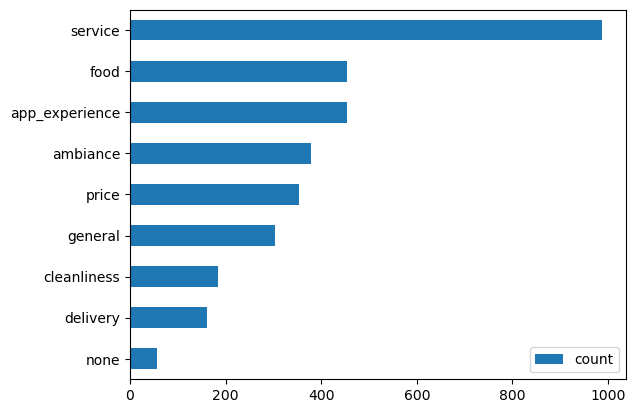

In [13]:
aspect_df.sort_values(by='count').plot(kind='barh')

In [15]:
sentiment_counter = Counter()

for d in train['aspect_sentiments']:
    sentiment_counter.update(d.values())

print(sentiment_counter)

Counter({'positive': 1646, 'negative': 1538, 'neutral': 149})


<Axes: >

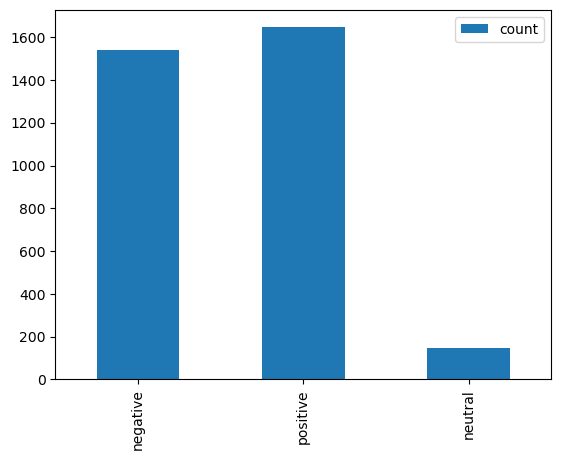

In [16]:
sent_df = pd.DataFrame.from_dict(sentiment_counter, orient='index', columns=['count'])
sent_df.plot(kind='bar')

In [18]:
combo_counter = Counter()

for d in train['aspect_sentiments']:
    for k, v in d.items():
        combo_counter[(k, v)] += 1

combo_counter

Counter({('service', 'positive'): 529,
         ('service', 'negative'): 449,
         ('app_experience', 'negative'): 327,
         ('ambiance', 'positive'): 268,
         ('general', 'positive'): 255,
         ('food', 'positive'): 246,
         ('price', 'negative'): 233,
         ('food', 'negative'): 177,
         ('delivery', 'negative'): 142,
         ('app_experience', 'positive'): 111,
         ('price', 'positive'): 110,
         ('cleanliness', 'positive'): 109,
         ('ambiance', 'negative'): 101,
         ('cleanliness', 'negative'): 75,
         ('none', 'neutral'): 57,
         ('general', 'negative'): 34,
         ('food', 'neutral'): 31,
         ('delivery', 'positive'): 18,
         ('app_experience', 'neutral'): 15,
         ('general', 'neutral'): 14,
         ('price', 'neutral'): 11,
         ('service', 'neutral'): 10,
         ('ambiance', 'neutral'): 9,
         ('cleanliness', 'neutral'): 1,
         ('delivery', 'neutral'): 1})

In [19]:
train['num_aspects'] = train['aspects'].apply(len)
train['num_aspects'].value_counts()

num_aspects
1    1066
2     552
3     266
4      71
5      15
6       1
Name: count, dtype: int64

In [20]:
train[train['aspects'].apply(lambda x: x == ['none'])].head()

,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments,length,has_emoji,num_aspects
5,8003,لقد حملت تطبيق عن طريق مستر بيست واريد سيارة ت...,1,2024-08-17 00:00:00,Shop,ecommerce,play_store,[none],{'none': 'neutral'},50,False,1
151,7673,شكران,5,2026-03-12 00:00:00,Amazon,ecommerce,play_store,[none],{'none': 'neutral'},5,False,1
171,8016,انا حملت هذا التطبيق من مستر بيست واتمني أن يح...,5,2024-04-14 00:00:00,Shop,ecommerce,play_store,[none],{'none': 'neutral'},63,False,1
173,115,Shady,5,قبل 11 ساعة,شتيجنبرجر,فندق,google_maps,[none],{'none': 'neutral'},5,False,1
227,4995,لوكيشن خطأ,1,قبل سنتين,كازارى,متجر ملابس رجالي,google_maps,[none],{'none': 'neutral'},10,False,1


In [21]:
train['platform'].value_counts()

platform
google_maps    1210
play_store      761
Name: count, dtype: int64

In [22]:
train['business_category'].value_counts().head(20)

business_category
ecommerce             212
مطعم                  150
transport             129
travel                121
entertainment         117
real_estate           100
عِيادة أسنان           89
food_delivery          82
مستشفى                 79
مطعم مأكولات سورية     77
صالون تجميل            75
مطعم مأكولات مشوية     75
مطعم بيتزا             53
فندق                   53
مطعم فلافل             42
مقهى                   42
صيدلية                 34
كافيه                  27
مطعم أطباق اللحوم      27
صالة رياضة             27
Name: count, dtype: int64

In [23]:
train['star_rating'].value_counts()

star_rating
5    987
1    661
3    146
4     99
2     78
Name: count, dtype: int64

In [24]:
train.groupby('star_rating')['aspect_sentiments'].count()

star_rating
1    661
2     78
3    146
4     99
5    987
Name: aspect_sentiments, dtype: int64